# 02 -- Build both label formats, and the shared split

Turns every downloaded chip's building-footprint polygons into **both**
`data/unet/` (image + binary mask) and `data/yolo/` (image + YOLO-format box file),
from the exact same source geometries -- and writes the one train/val/test split
(`data/split.json`) both model notebooks (03, 04) will read from.

**Prerequisite:** `python scripts/download_data.py --n 300` (or however many)
run first, from the repo root.

In [1]:
import sys
sys.path.insert(0, '..')

import glob
import os

import geopandas as gpd
import numpy as np
import rasterio
from PIL import Image

from src.labels import (
    filter_polygon_geometries,
    format_yolo_label_file,
    polygons_to_yolo_boxes,
    rasterize_polygons,
)
from src.split import save_split, split_chip_ids


## Find every downloaded chip

In [2]:
raw_images = sorted(glob.glob('../data/raw/images/img*.tif'))
chip_ids = [os.path.basename(p).replace('img', '').replace('.tif', '') for p in raw_images]
print(f'{len(chip_ids)} chips found')


20 chips found


## The one shared split

Written once, read by both the U-Net and YOLO training notebooks -- this is what
guarantees they're evaluated on exactly the same held-out chips.

In [3]:
split = split_chip_ids(chip_ids)
save_split(split, '../data/split.json')
print({k: len(v) for k, v in split.items()})


{'train': 14, 'val': 3, 'test': 3}


## Build both label formats for every chip

`filter_polygon_geometries` first (drops any stray non-Polygon geometry -- see the
notebook 01 finding), then the same filtered geometries feed both `rasterize_polygons`
(U-Net) and `polygons_to_yolo_boxes` (YOLO).

In [4]:
def to_uint8_rgb(path):
    """SpaceNet's PS-RGB chips are 16-bit; both U-Net and YOLO training
    pipelines expect normal 8-bit images -- this is the one place that
    conversion happens, so both models see identical pixel values."""
    with rasterio.open(path) as src:
        arr = src.read([1, 2, 3]).astype('float32')
        height, width = src.shape
        transform = src.transform
    p2, p98 = np.percentile(arr, (2, 98))  # simple contrast stretch, per-chip
    arr = np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1) * 255
    arr = arr.astype('uint8').transpose(1, 2, 0)  # CHW -> HWC for PIL
    return arr, height, width, transform


os.makedirs('../data/unet/images', exist_ok=True)
os.makedirs('../data/unet/masks', exist_ok=True)
os.makedirs('../data/yolo/images', exist_ok=True)
os.makedirs('../data/yolo/labels', exist_ok=True)

total_buildings = 0
total_filtered_out = 0
building_pixel_fractions = []

for chip_id in chip_ids:
    rgb, height, width, transform = to_uint8_rgb(f'../data/raw/images/img{chip_id}.tif')
    raw_geoms = gpd.read_file(f'../data/raw/labels/img{chip_id}.geojson').geometry
    geoms = filter_polygon_geometries(raw_geoms)
    total_buildings += len(geoms)
    total_filtered_out += len(raw_geoms) - len(geoms)

    mask = rasterize_polygons(geoms, height, width, transform)
    building_pixel_fractions.append(mask.mean())

    Image.fromarray(rgb).save(f'../data/unet/images/img{chip_id}.png')
    Image.fromarray(mask * 255).save(f'../data/unet/masks/img{chip_id}.png')

    boxes = polygons_to_yolo_boxes(geoms, width, height, transform)
    Image.fromarray(rgb).save(f'../data/yolo/images/img{chip_id}.png')
    with open(f'../data/yolo/labels/img{chip_id}.txt', 'w') as f:
        f.write(format_yolo_label_file(boxes))

print(f'{len(chip_ids)} chips processed')
print(f'{total_buildings} real buildings kept, {total_filtered_out} degenerate geometries filtered out')
print(f'mean building-pixel fraction per chip: {np.mean(building_pixel_fractions):.3f}')


20 chips processed
593 real buildings kept, 1 degenerate geometries filtered out
mean building-pixel fraction per chip: 0.171


## Write per-split image lists + YOLO's `data.yaml`

All chips' images live in one flat `data/yolo/images/` directory -- Ultralytics
supports pointing `train`/`val`/`test` at plain text files listing which image paths
belong to each split, rather than requiring separate directories per split. This is
what actually wires the *same* `data/split.json` train/val/test chip ids into YOLO's
training run -- without this, `train`/`val`/`test` would each default to the same
flat directory and YOLO would be "evaluated" on images it trained on, which would
make notebook 05's whole comparison meaningless.

In [5]:
for split_name, ids in split.items():
    with open(f'../data/yolo/{split_name}.txt', 'w') as f:
        f.write('\n'.join(f'images/img{cid}.png' for cid in ids))

data_yaml = '''path: ../data/yolo
train: train.txt
val: val.txt
test: test.txt
names:
  0: building
'''
with open('../data/yolo/data.yaml', 'w') as f:
    f.write(data_yaml)
print(data_yaml)


path: ../data/yolo
train: train.txt
val: val.txt
test: test.txt
names:
  0: building



## Verify: one sample chip's mask and boxes actually agree

The same check as `tests/test_labels.py::test_mask_and_boxes_agree_on_which_buildings_exist`,
here against a real chip instead of synthetic geometries.

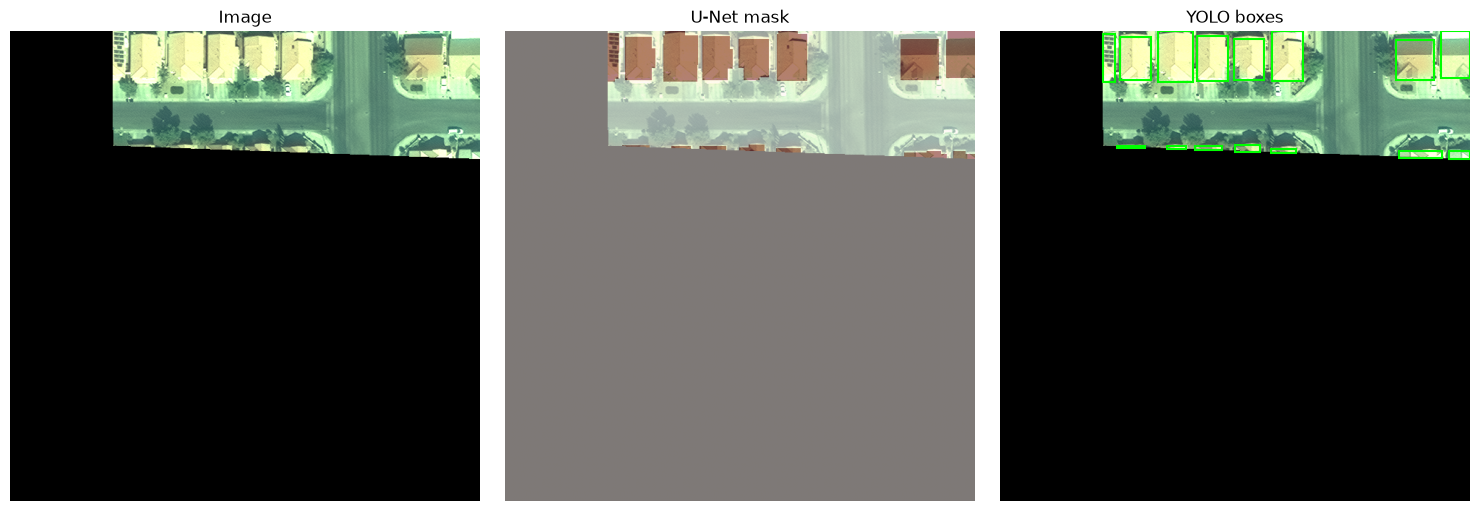

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_id = chip_ids[0]
img = np.array(Image.open(f'../data/unet/images/img{sample_id}.png'))
mask = np.array(Image.open(f'../data/unet/masks/img{sample_id}.png'))
with open(f'../data/yolo/labels/img{sample_id}.txt') as f:
    lines = [ln.split() for ln in f.read().splitlines() if ln.strip()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title('Image')
axes[1].imshow(img); axes[1].imshow(mask, alpha=0.5, cmap='Reds'); axes[1].set_title('U-Net mask')
axes[2].imshow(img); axes[2].set_title('YOLO boxes')
h, w = mask.shape
for _, x, y, bw, bh in lines:
    x, y, bw, bh = float(x) * w, float(y) * h, float(bw) * w, float(bh) * h
    rect = patches.Rectangle((x - bw / 2, y - bh / 2), bw, bh, linewidth=1.5, edgecolor='lime', facecolor='none')
    axes[2].add_patch(rect)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## Done when

- [x] `data/split.json` exists with train/val/test chip ids, no id repeated across splits.
- [x] Every chip has an image+mask pair under `data/unet/` and an image+label pair under
  `data/yolo/`.
- [x] `data/yolo/{train,val,test}.txt` each list only their own split's chip images.
- [x] The sample figure above shows the mask and the YOLO boxes both landing on the same
  real buildings.